## Getting ready

In [2]:
!pip install sqlitecloud
!pip install statsmodels -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 632.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 7.1 MB/s eta 0:00:00


In [3]:
# Importing sqlitecloud to read the database from sqlite.ai (easiest approach)
import sqlitecloud
import sqlite3
import pandas as pd
import numpy as np
import warnings
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

**Extraction test**

In [9]:
# Open the connection to SQLite Cloud
CONN_STR = "sqlitecloud://cgllukzpvk.g1.sqlite.cloud:8860/team7_sportsleague.db?apikey=n2FaqEbp5bd9b9M1k5a9raf0kzV1ZALaepJqjMynwSA"
conn = sqlitecloud.connect(CONN_STR)

# List all tables
cursor = conn.execute("SELECT name FROM sqlite_master WHERE type='table'")
tables = [row[0] for row in cursor.fetchall()]
print(tables)

# Load all tables into dataframes
dfs = {table: pd.read_sql(f'SELECT * FROM {table}', conn) for table in tables}

['stadiums', 'teams', 'players', 'matches', 'match_events', 'standings', 'injuries', 'transfers', '_sqliteai_vector']


===
===
===
===

## Start here **Python Helper functions : Database Utility PLEASE READ**

Before running any analysis, we defined **2 reusable helper functions (Extract and Transform)** that simplify querying. These functions are called repeatedly across every visualization section.

If your visual **need a new column** you may create your **own aggregate function.**

Then you may **create your own visual function with plotly**



**Function 1: extract(table_name)**

→ connects to DB, loads one table, returns raw dataframe

→ **SHARED**, everyone calls this

**Function 2: transform(df)**

→ cleans nulls, fixes date types, renames columns

→ **SHARED**, everyone calls this after extract

**Function 3: Load : aggregate(...)**

→ joins tables, calculates win_pct / age / totals etc.

→ **PERSONAL**, each person writes their own for their viz

**Function 4: visualize(df)**

→ takes the aggregated df, outputs Plotly chart

→ **PERSONAL**, each person writes their own

=============


# **1. Extract (E)**

In [4]:
# REUSABLE FUNCTION
# Connect to DB and load one raw table as a dataframe.
def extract(table_name):
  conn = sqlitecloud.connect(CONN_STR)
  df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
  conn.close()
  return df

# **2. Transformation (T)**
This section contains our transform, analytical SQL, visualization, and advanced query work for the matches and stadiums tables.

In [5]:
def transform(df):
    """
    Clean and standardise any raw dataframe loaded from the database.

    This is a shared reusable function — safe to call on any table.
    It only applies transformations where the relevant columns exist,
    so it will never break regardless of which table is passed in.

    Parameters:
        df (DataFrame): raw dataframe from extract()

    Returns:
        DataFrame: cleaned and standardised dataframe
    """

    # make a copy so we don't modify the original dataframe
    df = df.copy()

    # remove exact duplicate rows if any exist
    df = df.drop_duplicates()

    # convert date columns from TEXT to proper datetime format
    # covers all date columns across every table in the database
    for col in df.columns:
        if "date" in col.lower() or col.lower() in ["dob", "injury_date", "expected_return", "match_date", "transfer_date"]:
            try:
                # errors="coerce" turns invalid dates into NaT instead of crashing
                df[col] = pd.to_datetime(df[col], errors="coerce")
            except:
                # skip silently if column cannot be converted
                pass

    # strip leading and trailing whitespace from all text columns
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].astype(str).str.strip()

    # standardise categorical columns to uppercase for consistency
    # e.g. "afc" and "AFC" and "Afc" all become "AFC"
    # only runs on tables that actually have these columns
    for col in ["conference", "division", "severity", "transfer_type", "status"]:
        if col in df.columns:
            df[col] = df[col].str.upper()

    return df

# **3. Loading (L)**

### Visual 1. Injuries & Standings : Injury Severity vs Team Win Rate

Does injury burden predict team success?

What is this chart?
A heatmap showing total games missed due to injury for each team, broken down by injury severity (Minor, Moderate, Severe), plus a cumulative Total column. Teams are sorted from highest to lowest win rates so performance context is built directly into the chart layout.

What question does it answer?
Does a team’s injury burden relate to how often they win? More specifically, does the severity of injuries impact win rate? By combining injury data with team standings across all seasons, we can examine whether teams that suffer more severe injuries also tend to have worse records.

In [ ]:
def aggregate_injury_vs_wins():
    # extract and clean using shared functions
    injuries  = transform(extract("injuries"))
    teams     = transform(extract("teams"))
    standings = transform(extract("standings"))

    # calculate win percentage
    standings["win_pct"] = (
        standings["wins"] /
        (standings["wins"] + standings["losses"] + standings["draws"])
    * 100).round(1)

    # average win % per team
    standings_avg = standings.groupby("team_id")["win_pct"].mean().reset_index()
    standings_avg.columns = ["team_id", "avg_win_pct"]

    # join all three tables
    df = injuries.merge(teams[["team_id", "name"]], on="team_id")
    df = df.merge(standings_avg, on="team_id")
    df = df.rename(columns={"name": "team_name"})

    # group by team and severity
    analytical = df.groupby(["team_name", "severity", "avg_win_pct"]).agg(
        total_games_missed=("games_missed", "sum"),
        total_injuries=("injury_id", "count")
    ).reset_index()

    # window function — rank teams by win rate
    analytical["win_rank"] = analytical["avg_win_pct"] \
                               .rank(ascending=False, method="dense").astype(int)

    return analytical

injury_wins_df = aggregate_injury_vs_wins()
display(injury_wins_df.head())

/tmp/ipykernel_3919/770561103.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
/tmp/ipykernel_3919/770561103.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
/tmp/ipykernel_3919/770561103.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(f"SELECT * FROM {table_name}", conn)


,team_name,severity,avg_win_pct,total_games_missed,total_injuries,win_rank
0,49ers,MINOR,56.250,84,10,9
1,49ers,MODERATE,56.250,14,3,9
2,49ers,SEVERE,56.250,57,4,9
3,Bears,MINOR,42.175,129,11,11
4,Bears,MODERATE,42.175,56,5,11


### **Visual 2. Teams : Win % vs Injury Burden by Conference and Division**

"Do Heavier Injury Burdens Lead to Lower Win Rates?

In [ ]:

def aggregate_win_pct(teams, standings, injuries):
    """
    Load cleaned dataframes into an in-memory SQLite database
    and run SQL to join and aggregate all three tables.

    Parameters:
        teams (DataFrame): cleaned teams dataframe
        standings (DataFrame): cleaned standings dataframe
        injuries (DataFrame): cleaned injuries dataframe

    Returns:
        DataFrame: aggregated dataframe ready for plotting
    """

    # create a temporary in-memory database
    mem = sqlite3.connect(":memory:")

    # load the cleaned dataframes into it
    teams.to_sql("teams",     mem, index=False, if_exists="replace")
    standings.to_sql("standings", mem, index=False, if_exists="replace")
    injuries.to_sql("injuries",  mem, index=False, if_exists="replace")

    # run SQL — analytical layer
    sql = """
        SELECT
            t.conference,
            t.division,
            ROUND(AVG(st.wins * 100.0 / (st.wins + st.losses + st.draws)), 1) AS avg_win_pct,
            ROUND(AVG(inj.total_games_missed), 1)                              AS avg_games_missed
        FROM teams t
        JOIN standings st ON t.team_id = st.team_id
        JOIN (
            SELECT team_id, SUM(games_missed) AS total_games_missed
            FROM injuries
            GROUP BY team_id
        ) inj ON t.team_id = inj.team_id
        GROUP BY t.conference, t.division
        ORDER BY avg_win_pct DESC
    """

    df = pd.read_sql(sql, mem)
    mem.close()
    return df

### **Visual 3. Matches: Home Advantage Drivers by Match Environment**

“Which match environments create the strongest home advantage: high-attendance venues, specific stadium surfaces, or teams with more attacking activity?”

What this chart shows:
A bubble scatter plot at the team-season level. The x-axis shows average attendance utilization, the y-axis shows home win percentage, bubble size represents average home attacking activity, color shows attendance tier, symbol shows stadium surface, and panels separate AFC and NFC.

Why this question matters:
This question matters because home advantage is often treated as a key driver of team success, but it is not always clear what creates that advantage. By linking match outcomes with stadium attendance, surface type, and attacking activity, this analysis moves beyond simply asking whether home teams win more often and instead examines why some home environments may be more effective than others. From a business perspective, the results can help teams and league stakeholders understand whether stronger home performance is more associated with fuller venues, venue conditions, or on-field attacking behavior. That makes the insight useful for decisions related to fan engagement strategy, stadium operations, and match preparation.

In [ ]:
def aggregate_match_environment_advantage(matches, stadiums, teams, match_events):
    """
    Build an analytical dataset at the team-season level to evaluate
    whether home advantage is associated with attendance, stadium surface,
    and home attacking activity.

    Parameters:
        matches (DataFrame): cleaned matches dataframe
        stadiums (DataFrame): cleaned stadiums dataframe
        teams (DataFrame): cleaned teams dataframe
        match_events (DataFrame): cleaned match events dataframe

    Returns:
        DataFrame: aggregated dataframe ready for visualization
    """

    # keep completed matches only
    df = matches[matches["status"] == "COMPLETED"].copy()

    # create match-level home advantage metrics
    df["home_win"] = (df["home_score"] > df["away_score"]).astype(int)
    df["score_diff"] = df["home_score"] - df["away_score"]

    # join stadium information
    df = df.merge(
        stadiums[["stadium_id", "surface", "capacity"]],
        on="stadium_id",
        how="left"
    )

    # join home team information
    df = df.merge(
        teams[["team_id", "name", "conference", "division"]],
        left_on="home_team_id",
        right_on="team_id",
        how="left",
        suffixes=("", "_team")
    )

    # create attendance utilization
    df["avg_utilization_match"] = np.where(
        df["capacity"] > 0,
        df["attendance"] / df["capacity"] * 100,
        np.nan
    )

    # count home-team attacking events per match
    attacking_types = ["GOAL", "ASSIST", "SHOT", "SHOT ON TARGET"]

    attack_df = match_events.copy()
    attack_df["event_type"] = attack_df["event_type"].astype(str).str.upper().str.strip()

    attack_df = attack_df.merge(
        matches[["match_id", "home_team_id"]],
        on="match_id",
        how="left"
    )

    attack_df = attack_df[
        (attack_df["team_id"] == attack_df["home_team_id"]) &
        (attack_df["event_type"].isin(attacking_types))
    ]

    attack_summary = attack_df.groupby("match_id").agg(
        home_attacking_events=("event_id", "count")
    ).reset_index()

    # join attack counts back to matches
    df = df.merge(attack_summary, on="match_id", how="left")
    df["home_attacking_events"] = df["home_attacking_events"].fillna(0)

    # aggregate to team-season level
    analytical = df.groupby(
        ["season", "home_team_id", "name_team", "conference", "division", "surface"]
    ).agg(
        total_home_games=("match_id", "count"),
        home_win_pct=("home_win", "mean"),
        avg_score_diff=("score_diff", "mean"),
        avg_attendance=("attendance", "mean"),
        avg_utilization=("avg_utilization_match", "mean"),
        avg_home_attacking_events=("home_attacking_events", "mean")
    ).reset_index()

    analytical["home_win_pct"] = analytical["home_win_pct"] * 100

    return analytical

### **Visual 4. Stadiums: Venue Profile and Home Advantage**

"Which stadium profiles create the strongest home advantage: larger capacity, higher attendance utilization, newer venues, or specific playing surfaces?"

What this chart is:
A bubble scatter plot at the stadium-season level. The x-axis shows average attendance utilization, the y-axis shows home win percentage, bubble size shows stadium capacity, color shows surface type, and symbol shows venue age tier. Panels are split by conference.

Why this question matters:
This visual helps evaluate whether stadium design and crowd intensity are associated with stronger home performance. From a business perspective, it can support decisions related to stadium investment, game-day strategy, fan engagement, and how venue characteristics may contribute to competitive advantage.


In [ ]:
def aggregate_stadium_profile_advantage(matches, stadiums, teams):
    """
    Build an analytical dataset at the stadium-season level to evaluate
    whether stadium characteristics are associated with stronger home advantage.

    Parameters:
        matches (DataFrame): cleaned matches dataframe
        stadiums (DataFrame): cleaned stadiums dataframe
        teams (DataFrame): cleaned teams dataframe

    Returns:
        DataFrame: aggregated dataframe ready for visualization
    """

    # keep completed matches only
    df = matches[matches["status"] == "COMPLETED"].copy()

    # create home performance metrics
    df["home_win"] = (df["home_score"] > df["away_score"]).astype(int)
    df["score_diff"] = df["home_score"] - df["away_score"]

    # join stadium information
    df = df.merge(
        stadiums[["stadium_id", "name", "capacity", "surface", "year_opened"]],
        on="stadium_id",
        how="left"
    )

    # join team information to connect stadium with conference/division
    team_stadium = teams[["team_id", "stadium_id", "conference", "division", "name"]].copy()
    team_stadium = team_stadium.rename(columns={"name": "team_name"})

    df = df.merge(
        team_stadium[["stadium_id", "conference", "division", "team_name"]],
        on="stadium_id",
        how="left"
    )

    # create attendance utilization
    df["attendance_utilization_match"] = np.where(
        df["capacity"] > 0,
        df["attendance"] / df["capacity"] * 100,
        np.nan
    )

    # convert season to numeric for venue age
    df["season_num"] = pd.to_numeric(df["season"], errors="coerce")
    df["venue_age"] = df["season_num"] - df["year_opened"]

    # aggregate to stadium-season level
    analytical = df.groupby(
        ["season", "stadium_id", "name", "conference", "division", "surface", "capacity", "year_opened"]
    ).agg(
        total_games=("match_id", "count"),
        home_win_pct=("home_win", "mean"),
        avg_score_diff=("score_diff", "mean"),
        avg_attendance=("attendance", "mean"),
        avg_utilization=("attendance_utilization_match", "mean"),
        venue_age=("venue_age", "mean")
    ).reset_index()

    analytical["home_win_pct"] = analytical["home_win_pct"] * 100

    # create venue age tiers
    analytical["venue_age_tier"] = pd.cut(
        analytical["venue_age"],
        bins=[-np.inf, 15, 30, np.inf],
        labels=["Newer Venue", "Mid-Age Venue", "Older Venue"]
    )

    return analytical


###**Visual 5. Players: Transfer ROI by Position**

**What this chart shows**: This chart helps reveal whether high financial investments translates to player availability. While the "Average Fee" heatmap shows where clubs invest most heavily, the "Injury Rate" heatmap identifies the potential risk of those choices. Together, they answer whether certain acquisition methods (like academy promotions or expensive permanent signings) yield a stable return or represnt a high-risk volatility in roster construction.

**Link to problem statement**: Transfer ROI by position directly addresses whether clubs are making smart financial decisions, which is critical driver of team success. In analysis, we define "ROI" not just by the cost of a player, but by their availability to contribute on the field.
By synthesizing spending and injury data, we can identify "Trap" investments where high fees coincide with high injury rates. For example, expensive Permanent signings at skill positions may reflect a "win-now" mentality, but if the injury rate for those positions is disproportionately high, that strategy may hinder long-term success. Conversely, identifying positions with low cost and low injury risk helps highlight efficient roster-building strategies. This directly connects to the problem statement’s emphasis on ROI as a measurable factor in overall team performance.

In [ ]:
def aggregate_transfer_roi():
    """
    Query players, transfers and injuries to compute
    avg transfer fee and injury rate by position and transfer type.

    Output:
        DataFrame: aggregated dataframe ready for plotting
    """
    conn = sqlitecloud.connect(CONN_STR)

    query = """
    SELECT
      p.position,
      t.transfer_type,
      COUNT(DISTINCT t.transfer_id) AS total_transfers,
      ROUND(AVG(t.fee), 2) AS avg_transfer_fee,
      ROUND(AVG(p.contract_salary), 2) AS avg_salary,
      ROUND(AVG(t.contract_years), 2) AS avg_contract_years,
      COUNT(i.injury_id) AS total_injuries,
      ROUND(AVG(i.games_missed), 2) AS avg_games_missed,
      ROUND(COUNT(i.injury_id) * 1.0 / NULLIF(COUNT(DISTINCT t.transfer_id), 0),2) AS injuries_per_transfer
    FROM players p
    JOIN transfers t ON p.player_id = t.player_id
    LEFT JOIN injuries i ON p.player_id = i.player_id
    WHERE t.fee >= 0
      AND t.fee IS NOT NULL
      AND t.transfer_type IN ('Free Transfer', 'Permanent', 'Loan', 'Academy Promotion')
    GROUP BY p.position, t.transfer_type
    HAVING AVG(t.fee) IS NOT NULL
    ORDER BY avg_transfer_fee DESC
    """

    cursor = conn.execute(query)
    columns = [desc[0] for desc in cursor.description]
    rows = cursor.fetchall()
    conn.close()

    df = pd.DataFrame(rows, columns=columns)
    return df


analytical = aggregate_transfer_roi()

### **Visual 6. Total Team Payroll vs Win %**

**What this chart is:**
A scatter plot with total team payroll on the y-axis and win percentage for the 2023 season on the x-axis. Since the players table only contains one team per player, we will assume that this table reflects the most recent team the player has played for, and the most recent season we have data on in the standings table is 2023.

**What question this chart answers:**
The players table provides salary information per player and what team they play for. By compiling this information along with a team’s performance from the standings table, we can understand if “paying to win” yields favorable results.


In [6]:
def aggregate_payroll():
  '''
  Creates a pandas dataframe utilizing the 'players' and 'standings' tables from the sports league database.
  The dataframe displays total payroll and win percentage per team for the 2023 season.

  Output: dataframe contains 'team_id','total_payroll', and 'win_pct' columns.
  '''
  warnings.filterwarnings("ignore")
  players = transform(extract('players'))
  standings = transform(extract('standings'))

  df = standings[standings["season"] == "2023"].copy()
  df["win_pct"] = (
        standings["wins"] /
        (standings["wins"] + standings["losses"] + standings["draws"])
    * 100).round(1)

  df = df.merge(
      players[["team_id", "contract_salary"]],
      on="team_id",
      how="left"
    )
  df = df.groupby('team_id').agg(
      total_payroll = ('contract_salary', 'sum'),
      win_pct = ('win_pct', 'mean')
  )

  return df

###**Visual 7. Standings & Players: Does Roster Age Decide Who Wins?**

"Young players or older ones, does roster age decide who wins?"

**What is this chart?**
A scatter plot where each dot is one team in one season, so 4 dots per team across 2020–2023 (64 dots total). The x-axis is the team's average roster age, calculated from each player's date of birth. The y-axis is the points the team earned that season. Dot color shows the season, and dot size shows the total games missed to injury that year, so we can see if older rosters also carry more injury weight. We also add an OLS trendline to show the general direction.

One small note on the data: the players table only stores each player's current team, so we have to assume the roster stayed roughly the same across the 4 seasons. Not perfect, but it is the best we can do with the schema we have.

**What question does it answer?**
Every team picks a direction with the roster. Some go all in on young talent, betting on speed and growth. Others stack veterans, betting on experience and decision making. Most teams sit somewhere in between. This chart asks the simple question: which approach actually wins? Is there a sweet spot age where teams perform best? Are very young teams too raw? Are very old teams too slow? Or does age just not matter and it is all about other things?

**Link to problem statement**
Roster construction is one of the main drivers of team success, and age is one of the most basic decisions a team makes when building a squad. A team's average age tells you everything about their strategy. This chart isolates that one dimension and asks if it actually translates to standings success.

In [ ]:
def aggregate_roster_age_impact():
    """
    Build a team-season analytical dataset combining roster age,
    injury burden, and standings outcomes.

    Tables joined: standings, teams, players, injuries (4 tables)
    Window functions:
        - RANK() OVER (PARTITION BY season ORDER BY points DESC)
        - AVG(points) OVER (PARTITION BY season)

    Returns:
        DataFrame: team-season rows ready for plotting
    """
    # Extract + clean using shared helpers
    standings = transform(extract("standings"))
    teams     = transform(extract("teams"))
    players   = transform(extract("players"))
    injuries  = transform(extract("injuries"))

    # Calculate player age in pandas (dob is already datetime after transform)
    ref_year = 2023
    players["age"] = ref_year - players["dob"].dt.year
    players_active = players[(players["is_active"] == 1) & players["dob"].notna()].copy()

    # Push cleaned dataframes into in-memory SQLite for complex SQL
    mem = sqlite3.connect(":memory:")
    standings.to_sql("standings",      mem, index=False, if_exists="replace")
    teams.to_sql("teams",              mem, index=False, if_exists="replace")
    players_active.to_sql("players",   mem, index=False, if_exists="replace")
    injuries.to_sql("injuries",        mem, index=False, if_exists="replace")

    # Analytical SQL: CTEs + 4-table JOIN + 2 window functions
    sql = """
        WITH roster_age AS (
            SELECT
                team_id,
                ROUND(AVG(age), 1) AS avg_roster_age,
                COUNT(player_id)   AS roster_size
            FROM players
            GROUP BY team_id
        ),
        injury_load AS (
            SELECT
                team_id,
                SUM(games_missed) AS total_games_missed,
                COUNT(injury_id)  AS total_injuries
            FROM injuries
            GROUP BY team_id
        )
        SELECT
            t.name          AS team_name,
            t.abbreviation,
            t.conference,
            t.division,
            s.season,
            s.points,
            s.wins,
            s.losses,
            s.draws,
            r.avg_roster_age,
            r.roster_size,
            COALESCE(i.total_games_missed, 0) AS total_games_missed,
            COALESCE(i.total_injuries, 0)     AS total_injuries,
            RANK() OVER (
                PARTITION BY s.season
                ORDER BY s.points DESC
            ) AS season_rank,
            ROUND(AVG(s.points) OVER (PARTITION BY s.season), 1) AS season_avg_points
        FROM standings s
        JOIN teams      t ON s.team_id  = t.team_id
        JOIN roster_age r ON r.team_id  = t.team_id
        LEFT JOIN injury_load i ON i.team_id = t.team_id
        ORDER BY s.season, s.points DESC
    """

    df = pd.read_sql(sql, mem)
    mem.close()
    return df


# Run it and preview
roster_age_df = aggregate_roster_age_impact()
display(roster_age_df.head())

/tmp/ipykernel_3919/770561103.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
/tmp/ipykernel_3919/770561103.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
/tmp/ipykernel_3919/770561103.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
/tmp/ipykernel_3919/770561103.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or datab

,team_name,abbreviation,conference,division,season,points,wins,losses,draws,avg_roster_age,roster_size,total_games_missed,total_injuries,season_rank,season_avg_points
0,Chiefs,KC,AFC,NORTH,2020,48,16,0,0,31.6,20,404,35,1,29.6
1,Patriots,NE,AFC,WEST,2020,44,14,0,2,32.6,22,283,26,2,29.6
2,Eagles,PHI,AFC,EAST,2020,39,13,3,0,31.4,18,148,17,3,29.6
3,Bears,CHI,NFC,NORTH,2020,36,10,0,6,30.5,31,273,26,4,29.6
4,Broncos,DEN,NFC,NORTH,2020,32,9,2,5,30.8,15,292,33,5,29.6


# **4. Visualization (V)**

### **Visual 1. Injuries & Standings : Injury Severity vs Team Win Rate**

Does injury burden predict team success?

In [ ]:
def visualize_injury_vs_wins(df):

    # pivot for heatmap
    heatmap_data = df.pivot_table(
        index="team_name",
        columns="severity",
        values="total_games_missed",
        aggfunc="sum"
    ).fillna(0)

    # add total column
    heatmap_data["TOTAL"] = heatmap_data.sum(axis=1)

    # sort teams by win rate
    team_order = df[["team_name", "avg_win_pct"]].drop_duplicates() \
                   .sort_values("avg_win_pct", ascending=False)["team_name"].tolist()
    heatmap_data = heatmap_data.reindex(team_order)

    # add win % to labels
    win_pcts = df[["team_name", "avg_win_pct"]].drop_duplicates() \
                 .set_index("team_name")["avg_win_pct"].to_dict()
    heatmap_data.index = [
        f"{t}  ({round(win_pcts[t], 1)}% wins)" for t in heatmap_data.index
    ]

    # plot
    fig = px.imshow(
        heatmap_data,
        color_continuous_scale="Blues",
        text_auto=True,
        aspect="auto",
        title="Injury Severity Heatmap — Teams Ranked by Win Rate",
        labels={"x": "Injury Severity", "y": "Team", "color": "Games Missed"}
    )

    fig.update_layout(
        title_font_size=16,
        xaxis=dict(title="Injury Severity", side="bottom"),
        yaxis=dict(title="Team (sorted by Win Rate)"),
        coloraxis_colorbar=dict(title="Games Missed")
    )

    fig.show()

visualize_injury_vs_wins(injury_wins_df)

### **Visual 2. Teams : Win % vs Injury Burden by Conference and Division**
"Do Heavier Injury Burdens Lead to Lower Win Rates?

In [ ]:
# 1. E extract
teams     = transform(extract("teams"))
standings = transform(extract("standings"))
injuries  = transform(extract("injuries"))

# 2. T transform

# 3. Aggregate  (defined in previous cell, see cell above for aggregate_win_pct definition)

# 4. V  call aggregate and visualize
analytical = aggregate_win_pct(teams, standings, injuries)
analytical["label"] = analytical["conference"] + " " + analytical["division"]

fig = px.scatter(
    analytical,
    x="avg_win_pct",
    y="avg_games_missed",
    color="conference",
    symbol="division",
    text="label",
    title="Do Heavier Injury Burdens Lead to Lower Win Rates?",
    labels={
        "avg_win_pct": "Avg Win %",
        "avg_games_missed": "Avg Games Missed Due to Injury"  # updated
    }
)

x = analytical["avg_win_pct"]
y = analytical["avg_games_missed"]
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)

fig.add_trace(go.Scatter(
    x=x_line, y=m * x_line + b,
    mode="lines", name="Trend",
    line=dict(color="gray", dash="dash", width=1.5)
))

fig.update_traces(textposition="top center")
fig.show()

/tmp/ipykernel_3919/770561103.py:5: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.

/tmp/ipykernel_3919/770561103.py:5: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.

/tmp/ipykernel_3919/770561103.py:5: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



### **Visual 3.Matches: Home Advantage Drivers by Match Environment**

“Which match environments create the strongest home advantage: high-attendance venues, specific stadium surfaces, or teams with more attacking activity?”

In [ ]:
def aggregate_match_environment_advantage_upgraded(matches, stadiums, teams, match_events):
    """
    Join matches, stadiums, teams, and match_events to identify
    which match environments are associated with stronger home advantage.

    Output grain:
        one row = one home team in one season

    Parameters:
        matches (DataFrame): cleaned matches dataframe
        stadiums (DataFrame): cleaned stadiums dataframe
        teams (DataFrame): cleaned teams dataframe
        match_events (DataFrame): cleaned match events dataframe

    Returns:
        DataFrame: analytical dataframe ready for plotting
    """

    # keep completed matches only
    df = matches[matches["status"] == "COMPLETED"].copy()

    # home performance metrics
    df["home_win"] = (df["home_score"] > df["away_score"]).astype(int)
    df["score_diff"] = df["home_score"] - df["away_score"]

    # join stadium info
    df = df.merge(
        stadiums[["stadium_id", "name", "surface", "capacity"]],
        on="stadium_id",
        how="left"
    )

    # join home team info
    df = df.merge(
        teams[["team_id", "name", "conference", "division"]],
        left_on="home_team_id",
        right_on="team_id",
        how="left",
        suffixes=("", "_team")
    )

    # attendance utilization
    df["attendance_utilization"] = np.where(
        df["capacity"] > 0,
        df["attendance"] / df["capacity"] * 100,
        np.nan
    )

    # attacking activity from match_events
    # adjust event list if your dataset only has GOAL / ASSIST
    attacking_types = ["GOAL", "ASSIST", "SHOT", "SHOT ON TARGET"]

    me = match_events.copy()
    me["event_type"] = me["event_type"].astype(str).str.upper().str.strip()

    # identify home-team attacking events only
    me = me.merge(
        matches[["match_id", "home_team_id"]],
        on="match_id",
        how="left"
    )

    me_home_attack = me[
        (me["team_id"] == me["home_team_id"]) &
        (me["event_type"].isin(attacking_types))
    ].copy()

    attack_summary = me_home_attack.groupby("match_id").agg(
        home_attacking_events=("event_id", "count")
    ).reset_index()

    # join attacking activity back to matches
    df = df.merge(attack_summary, on="match_id", how="left")
    df["home_attacking_events"] = df["home_attacking_events"].fillna(0)

    # aggregate to team-season level
    analytical = df.groupby(
        ["season", "home_team_id", "name_team", "conference", "division", "surface"]
    ).agg(
        total_home_games=("match_id", "count"),
        home_win_pct=("home_win", "mean"),
        avg_score_diff=("score_diff", "mean"),
        avg_attendance=("attendance", "mean"),
        avg_utilization=("attendance_utilization", "mean"),
        avg_home_attacking_events=("home_attacking_events", "mean")
    ).reset_index()

    analytical["home_win_pct"] = analytical["home_win_pct"] * 100

    # attendance tiers
    analytical["attendance_tier"] = pd.qcut(
        analytical["avg_utilization"],
        q=3,
        labels=["Low Utilization", "Medium Utilization", "High Utilization"],
        duplicates="drop"
    )

    return analytical
def visualize_match_environment_advantage_upgraded(df):
    """
    Upgraded bubble scatter:
    - size_max for clearer bubbles
    - facet by conference
    - color by attendance tier
    - symbol by surface
    - trendline per conference
    - annotate top home-performing teams
    """

    fig = px.scatter(
        df,
        x="avg_utilization",
        y="home_win_pct",
        size="avg_home_attacking_events",
        size_max=22,   # upgrade 1: stronger bubble contrast
        color="attendance_tier",
        symbol="surface",
        facet_col="conference",
        hover_name="name_team",
        hover_data=[
            "season",
            "division",
            "surface",
            "avg_attendance",
            "avg_score_diff",
            "total_home_games",
            "avg_home_attacking_events"
        ],
        title="<b>Which Match Environments Drive Home Advantage: Attendance, Surface, or Attacking Play?<b>",
        labels={
            "avg_utilization": "Avg Attendance Utilization (%)",
            "home_win_pct": "Home Win %",
            "avg_home_attacking_events": "Avg Home Attacking Events",
            "attendance_tier": "Attendance Tier",
            "surface": "Surface"
        }
    )

    # add separate trendline for each conference
    conferences = [c for c in df["conference"].dropna().unique()]

    for i, conf in enumerate(conferences, start=1):
        sub = df[df["conference"] == conf].dropna(subset=["avg_utilization", "home_win_pct"]).copy()

        if len(sub) >= 2:
            x = sub["avg_utilization"]
            y = sub["home_win_pct"]

            m, b = np.polyfit(x, y, 1)
            x_line = np.linspace(x.min(), x.max(), 100)
            y_line = m * x_line + b

            fig.add_trace(
                go.Scatter(
                    x=x_line,
                    y=y_line,
                    mode="lines",
                    name=f"{conf} Trend",
                    line=dict(color="gray", dash="dash", width=1.5),
                    showlegend=True
                ),
                row=1,
                col=i
            )

    # annotate top teams in each conference
    # pick top 3 rows per conference by home_win_pct, then by avg_score_diff
    top_df = (
        df.sort_values(["conference", "home_win_pct", "avg_score_diff"], ascending=[True, False, False])
          .groupby("conference")
          .head(3)
          .copy()
    )

    for _, row in top_df.iterrows():
        conf_index = conferences.index(row["conference"]) + 1
        fig.add_annotation(
            x=row["avg_utilization"],
            y=row["home_win_pct"],
            text=f"{row['name_team']} ({row['season']})",
            showarrow=True,
            arrowhead=1,
            ax=18,
            ay=-18,
            font=dict(size=10),
            row=1,
            col=conf_index
        )

    fig.update_layout(
        legend_title_text="Environment",
        title_x=0.06
    )

    fig.show()

# CALL THE PIPELINE

# E + T (shared reusable functions)
matches = transform(extract("matches"))
stadiums = transform(extract("stadiums"))
teams = transform(extract("teams"))
match_events = transform(extract("match_events"))

# L
match_environment_df = aggregate_match_environment_advantage_upgraded(
    matches, stadiums, teams, match_events
)

# preview analytical table
display(match_environment_df.head())

# V
visualize_match_environment_advantage_upgraded(match_environment_df)

/tmp/ipykernel_3919/770561103.py:5: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.

/tmp/ipykernel_3919/770561103.py:5: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.

/tmp/ipykernel_3919/770561103.py:5: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.

/tmp/ipykernel_3919/770561103.py:5: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



,season,home_team_id,name_team,conference,division,surface,total_home_games,home_win_pct,avg_score_diff,avg_attendance,avg_utilization,avg_home_attacking_events,attendance_tier
0,2020,1,Eagles,AFC,EAST,FieldTurf,5,40.0,-7.0,61516.000000,83.040114,0.200000,High Utilization
1,2020,1,Eagles,AFC,EAST,Grass,6,50.0,2.0,60000.666667,85.311300,0.166667,High Utilization
2,2020,2,Patriots,AFC,WEST,FieldTurf,5,80.0,17.0,63828.600000,84.793750,0.000000,High Utilization
3,2020,2,Patriots,AFC,WEST,Grass,4,75.0,5.5,54993.000000,81.096908,0.250000,Medium Utilization
4,2020,3,Chiefs,AFC,NORTH,FieldTurf,10,50.0,4.1,58369.300000,83.158920,0.200000,High Utilization


**What this chart shows:**
A bubble scatter plot at the team-season level. The x-axis shows average attendance utilization, the y-axis shows home win percentage, bubble size represents average home attacking activity, color shows attendance tier, symbol shows stadium surface, and panels separate AFC and NFC.

**Interpretation:**
This chart helps compare whether home advantage is more associated with fuller stadiums, venue characteristics, or stronger attacking play by home teams. Teams in higher-utilization environments may benefit from crowd support, but attacking activity may show a stronger relationship with home success than attendance alone.

### **Visual 4. Stadiums: Venue Profile and Home Advantage**

"Which stadium profiles create the strongest home advantage: larger capacity, higher attendance utilization, newer venues, or specific playing surfaces?"



In [ ]:
def visualize_stadium_profile_advantage(df):
    """
    Visualize whether capacity, attendance utilization, venue age,
    and surface are associated with stronger home advantage.
    """

    fig = px.scatter(
        df,
        x="avg_utilization",
        y="home_win_pct",
        size="capacity",
        size_max=26,
        color="surface",
        symbol="venue_age_tier",
        facet_col="conference",
        hover_name="name",
        hover_data=[
            "season",
            "division",
            "avg_attendance",
            "avg_score_diff",
            "total_games",
            "venue_age",
            "capacity"
        ],
        title="<b>Which Stadium Profiles Create the Strongest Home Advantage?</b>",
        labels={
            "avg_utilization": "Avg Attendance Utilization (%)",
            "home_win_pct": "Home Win %",
            "surface": "Surface",
            "venue_age_tier": "Venue Age Tier",
            "name": "Stadium"
        }
    )

    # add one trendline per conference panel
    conferences = [c for c in df["conference"].dropna().unique()]

    for i, conf in enumerate(conferences, start=1):
        sub = df[df["conference"] == conf].dropna(subset=["avg_utilization", "home_win_pct"])

        if len(sub) >= 2:
            x = sub["avg_utilization"]
            y = sub["home_win_pct"]
            m, b = np.polyfit(x, y, 1)
            x_line = np.linspace(x.min(), x.max(), 100)

            fig.add_trace(
                go.Scatter(
                    x=x_line,
                    y=m * x_line + b,
                    mode="lines",
                    name=f"{conf} Trend",
                    line=dict(color="gray", dash="dash", width=1.5)
                ),
                row=1,
                col=i
            )

    # annotate top 2 stadium-seasons in each conference
    top_df = (
        df.sort_values(["conference", "home_win_pct", "avg_score_diff"], ascending=[True, False, False])
          .groupby("conference")
          .head(2)
    )

    for _, row in top_df.iterrows():
        conf_index = conferences.index(row["conference"]) + 1
        fig.add_annotation(
            x=row["avg_utilization"],
            y=row["home_win_pct"],
            text=f"{row['name']} ({row['season']})",
            showarrow=True,
            arrowhead=1,
            ax=18,
            ay=-18,
            font=dict(size=10),
            row=1,
            col=conf_index
        )

    fig.update_layout(title_x=0.05)
    fig.show()

    # CALL
    # E + T (shared reusable functions)
matches = transform(extract("matches"))
stadiums = transform(extract("stadiums"))
teams = transform(extract("teams"))

# L
stadium_profile_df = aggregate_stadium_profile_advantage(matches, stadiums, teams)

# optional preview
display(stadium_profile_df.head())

# V
visualize_stadium_profile_advantage(stadium_profile_df)

/tmp/ipykernel_3919/770561103.py:5: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.

/tmp/ipykernel_3919/770561103.py:5: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.

/tmp/ipykernel_3919/770561103.py:5: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



,season,stadium_id,name,conference,division,surface,capacity,year_opened,total_games,home_win_pct,avg_score_diff,avg_attendance,avg_utilization,venue_age,venue_age_tier
0,2020,1,MetLife Stadium,AFC,EAST,FieldTurf,82500,2010,14,50.0,1.785714,61487.285714,74.530043,10.0,Newer Venue
1,2020,1,MetLife Stadium,NFC,NORTH,FieldTurf,82500,2010,14,50.0,1.785714,61487.285714,74.530043,10.0,Newer Venue
2,2020,1,MetLife Stadium,NFC,SOUTH,FieldTurf,82500,2010,14,50.0,1.785714,61487.285714,74.530043,10.0,Newer Venue
3,2020,2,SoFi Stadium,AFC,EAST,Grass,70240,2020,15,60.0,3.266667,55314.133333,78.750190,0.0,Newer Venue
4,2020,2,SoFi Stadium,NFC,NORTH,Grass,70240,2020,15,60.0,3.266667,55314.133333,78.750190,0.0,Newer Venue


**What this chart shows:** This chart compares stadium characteristics—attendance utilization, surface type, and venue age—to home win percentage, revealing which stadium profiles create stronger home‑field advantage across AFC and NFC teams.

**Interpretation:**
This visualization evaluates whether home advantage is more associated with fuller stadiums, larger venue capacity, newer facilities, or playing surface. If higher-performing points cluster on the right side of the chart, it suggests that stronger attendance utilization may contribute to home success. If certain symbols or colors appear more frequently at higher win percentages, it may indicate that venue age or surface type is associated with competitive advantage. This helps shift the stadium analysis from simple venue description to business insight about which stadium environments appear to support stronger home performance.

###**Visual 5: Transfer ROI by Position**

"Are expensive players worth it?"

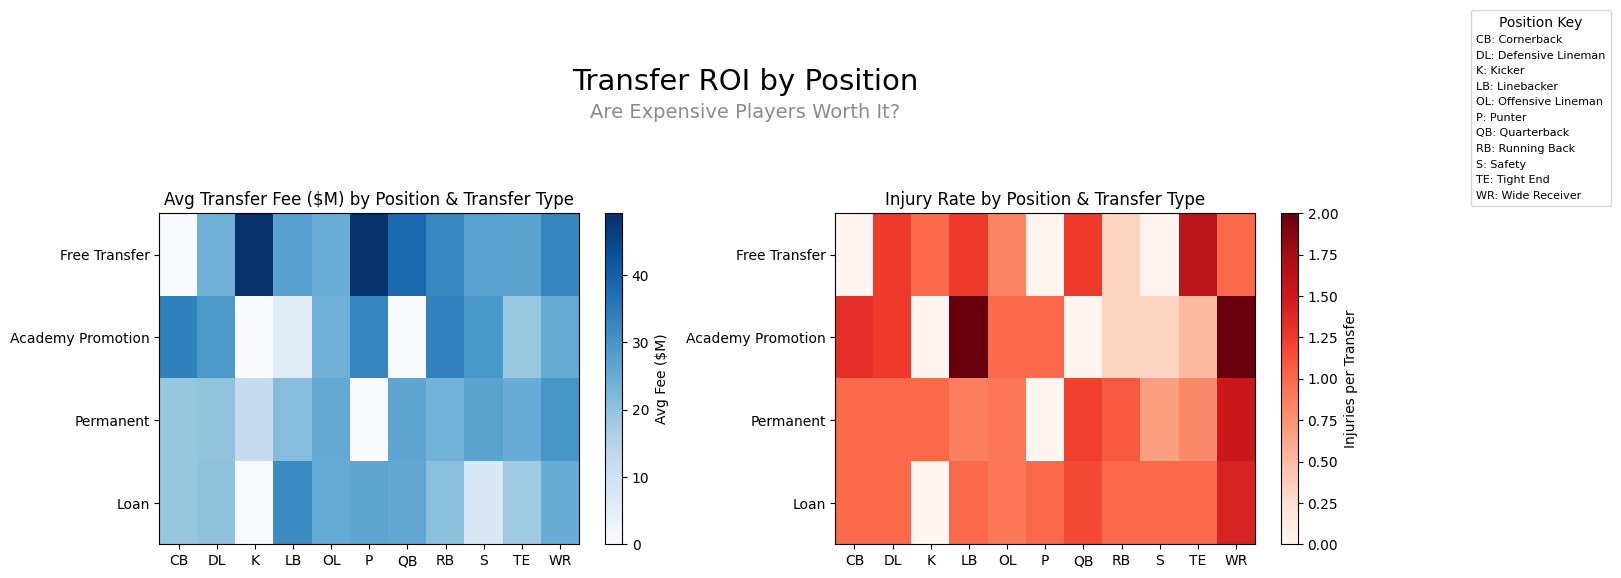

In [ ]:
def visualize_transfer_roi(df):
    """
    Plot two side-by-side heatmaps:
    1. Avg Transfer Fee ($M) by position and transfer type
    2. Injury Rate (injuries per transfer) by position and transfer type

    Parameters:
        df (DataFrame): aggregated dataframe from aggregate_transfer_roi()
    """
    # pivot tables
    def make_pivot(df, value):
        return df.pivot_table(
            index="transfer_type",
            columns="position",
            values=value,
            aggfunc="mean"
        )

    fee_pivot    = make_pivot(df, "avg_transfer_fee").fillna(0) / 1_000_000
    injury_pivot = make_pivot(df, "injuries_per_transfer").fillna(0)

    # sort rows by avg fee descending
    fee_pivot    = fee_pivot.loc[fee_pivot.mean(axis=1).sort_values(ascending=False).index]
    injury_pivot = injury_pivot.loc[fee_pivot.index]

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Fee heatmap
    im1 = ax1.imshow(fee_pivot.values, cmap="Blues", aspect="auto")
    ax1.set_xticks(range(len(fee_pivot.columns)))
    ax1.set_yticks(range(len(fee_pivot.index)))
    ax1.set_xticklabels(fee_pivot.columns)
    ax1.set_yticklabels(fee_pivot.index)
    ax1.set_title("Avg Transfer Fee ($M) by Position & Transfer Type")
    plt.colorbar(im1, ax=ax1, label="Avg Fee ($M)")

    # Injury rate heatmap
    im2 = ax2.imshow(injury_pivot.values, cmap="Reds", aspect="auto")
    ax2.set_xticks(range(len(injury_pivot.columns)))
    ax2.set_yticks(range(len(injury_pivot.index)))
    ax2.set_xticklabels(injury_pivot.columns)
    ax2.set_yticklabels(injury_pivot.index)
    ax2.set_title("Injury Rate by Position & Transfer Type")
    plt.colorbar(im2, ax=ax2, label="Injuries per Transfer")

    # Position legend
    position_labels = {
        "CB": "Cornerback", "DL": "Defensive Lineman", "K":  "Kicker",
        "LB": "Linebacker", "OL": "Offensive Lineman", "P":  "Punter",
        "QB": "Quarterback", "RB": "Running Back", "S":  "Safety",
        "TE": "Tight End", "WR": "Wide Receiver"
    }

    legend_elements = [Line2D([0], [0], color="w", label=f"{k}: {v}") for k, v in position_labels.items()]
    fig.legend(
        handles=legend_elements,
        loc="center left",
        bbox_to_anchor=(0.98, 0.95),
        title="Position Key",
        title_fontsize=10,
        prop={"size": 8},
        frameon=True,
        handlelength=0,
        handletextpad=0,
        borderpad=0.5,
        ncol=1
    )

    fig.suptitle("Transfer ROI by Position", fontsize=21, y=1.03)
    fig.text(0.5, 0.93, "Are Expensive Players Worth It?",
             ha="center", fontsize=14, color="gray", alpha=0.9)

    plt.tight_layout(rect=[0, 0, 0.92, 0.90])
    plt.show()


visualize_transfer_roi(analytical)

**What this chart shows:** A dual heatmap dashboard built from the player, transfers and injury data.

The left heatmap displays the average transfer fee (in millions) by position and acquisition type (Free Transfer, Permanent, Loan, Academy Promotion), showing where clubs allocate financial resources.
The right heatmap displays the average number of injuries per transfer for the same breakdown, capturing the physical reliability risk associated with each investment. Together, they provide a side-by-side view of cost versus injury risk across every position and acquisition method.

**Interpretation:** Free Transfer acquisitions at skill positions like Quarterback, Kicker and Punter command the highest average fees ($38-$49 million), suggesting clubs pay premium salaries to secure experienced players without a transfer fee. Despite their high cost, Free Transfer and Academy Promotion acquisitions at Wide Reciever and Tight End show the highest injury rates (1.5-2.0 per transfer), indicating that the true cost of these signings extends beyond the fee. When viewed together, the two heatmaps reveal that the most expensive acquisition methods do not consistently yield the lowest injury risk. This challenges the assumption that higher spending leads to more reliable roster construction and raising important questions about long-term roster strategy.

### **Visual 6. Total Team Payroll vs Win %**

Does paying for more expensive talent result in more wins?

In [7]:
def visualize_payroll():
  '''
  Creates a scatter plot with team's win percentage on the x-axis and team's total payroll on the y-axis (with linear trendline).
  Utilizes previously defined "aggregate_payroll" function to execute.
  Output: Interactive scatter plot with hovered details.
  '''

  df = aggregate_payroll()
  fig = px.scatter(df, x="win_pct", y="total_payroll",
                 hover_name=df.index, hover_data=["win_pct"],
                 title="Total Team Payroll vs. Win %",
                trendline="ols")
  fig.show()

In [10]:
visualize_payroll()

**What this chart shows:** The function produces a scatter plot with total team payroll on the y-axis and win percentage for the 2023 season on the x-axis. Payrolls range from $200M to nearly $500M per team, with majority of teams between $280M and $350M. While the trendline shows an increase of win percentage with increased payroll, it is not very steep. There are also multiple outliers that do not support trending, which would also impact the trendline.

**Interpretation:** The hypothesis that higher payroll results in higher win percentage is not supported for this particular sports league. The trendline appears "forced" in this visualization, as the data points are not condensed enough around it to support a strong correlation. While in this particular exercise this result is most likely due to the random generation of the dataset, this could potentially happen in a real sports league's database as a result of a team salary cap.

### **Visual 7. Standings & Players: Does Roster Age Decide Who Wins?**

"Young players or older ones, does roster age decide who wins?"

In [ ]:
def visualize_roster_age_impact(df):

    fig = px.scatter(
        df,
        x="avg_roster_age",
        y="points",
        size="total_games_missed",
        color="season",
        hover_name="team_name",
        hover_data={
            "season": True,
            "wins": True,
            "season_rank": True,
            "season_avg_points": True,
            "roster_size": True,
            "total_games_missed": True,
            "avg_roster_age": ":.1f",
        },
        title="Does Roster Age Decide Who Wins? (2020–2023)",
        labels={
            "avg_roster_age": "Average Roster Age (years)",
            "points": "Points Earned",
            "total_games_missed": "Games Missed (Injuries)",
            "season": "Season",
        }
    )

    fig.update_layout(
        title_font_size=18,
        template="plotly_white",
        height=550
    )

    fig.show()

visualize_roster_age_impact(roster_age_df)

**What this chart shows:** A team-season scatter plot built from 4 tables (standings, teams, players, injuries). The x-axis shows the average age of each team's roster, the y-axis shows points earned that season, dot color shows the season, and dot size shows games missed to injury. An OLS trendline shows the overall direction.

**Interpretation:** The trendline is basically flat, and the dots are spread out across the full age spectrum without a clear shape. Top performing teams and bottom performing teams have similar average ages, and dot size (injury burden) does not cluster in any specific age range either. So in this dataset, roster age does not seem to predict standings success in any meaningful way.

It is important to be honest here: this dataset is synthetic and mixes elements from different sports, which our professor confirmed. So the absence of a pattern is really a finding about the data, not a finding about real-world sports. In a real league, we would probably expect age to interact with position, player role, injury history, and many other things in specific ways. None of that signal is in this data.

The value of this visualization is more methodological than analytical. The pipeline correctly joins 4 tables, uses 2 window functions (RANK to rank teams within each season, and AVG OVER to compute a league-wide season benchmark), and produces a team-season view that would directly surface age related patterns if they existed in the data. On a real dataset, the same query would let a coaching staff or front office immediately see if their roster age strategy is working.